In [1]:
# ============================================================
# PRAKTIKUM PERTEMUAN 02 : PREPROCESSING DATA dan EDA
# ============================================================

import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Memuat dataset Titanic bawaan seaborn (891 penumpang, 15 kolom).
df = sns.load_dataset("titanic")

# 1) Missing value
# Kolom age punya banyak nilai kosong → diisi dengan median (nilai tengah).
# Kolom embarked (pelabuhan) → diisi dengan modus (nilai paling sering).
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 2) Duplikat
# Menghapus baris yang isinya 100% sama persis.
df = df.drop_duplicates()

# 3) Outlier sederhana (IQR) pada fare
# Menghitung batas bawah dan atas. Nilai di luar batas dipotong (clip).
q1, q3 = df["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
df["fare"] = df["fare"].clip(low, high)

# 4) Scaling
# StandardScaler mengubah data agar mean=0, std=1.
# Penting untuk algoritma yang sensitif terhadap skala (SVM, KNN, dll).
scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print(df[["age", "fare"]].describe())

                age          fare
count  7.810000e+02  7.810000e+02
mean   1.364679e-16 -6.141054e-17
std    1.000641e+00  1.000641e+00
min   -2.122937e+00 -1.166698e+00
25%   -5.541507e-01 -8.118984e-01
50%   -1.179728e-01 -4.659132e-01
75%    4.635977e-01  3.327529e-01
max    3.662236e+00  2.049730e+00


In [ ]:
# ============================================================
# TUGAS PRAKTIKUM PERTEMUAN 02
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Pastikan grafik muncul langsung di notebook
%matplotlib inline

# ==========================================
# 1. LOAD DATA
# ==========================================
# Membuat data penguin
np.random.seed(42)
n_samples = 300
data = {
    'bill_length_mm': np.random.normal(44, 5, n_samples),
    'bill_depth_mm': np.random.normal(17, 2, n_samples),
    'flipper_length_mm': np.random.normal(200, 14, n_samples),
    'body_mass_g': np.random.normal(4200, 800, n_samples),
    'species': np.random.choice(['Adelie', 'Chinstrap', 'Gentoo'], n_samples)
}
df = pd.DataFrame(data)

# Simulasi nilai hilang (soal no 2)
df.loc[0:5, 'body_mass_g'] = np.nan

print("--- 1. UKURAN DATA DAN TIPE KOLOM ---")
print(f"Ukuran Data: {df.shape}")
print("-" * 30)
print(df.info())
display(df.head())


--- 1. UKURAN DATA DAN TIPE KOLOM ---
Ukuran Data: (300, 5)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     300 non-null    float64
 1   bill_depth_mm      300 non-null    float64
 2   flipper_length_mm  300 non-null    float64
 3   body_mass_g        294 non-null    float64
 4   species            300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB
None


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,46.483571,15.342010,210.597841,NaN,Adelie
1,43.308678,15.879638,187.089685,NaN,Chinstrap
2,47.238443,18.494587,212.174483,NaN,Gentoo
3,51.615149,18.220741,218.978930,NaN,Gentoo
4,42.829233,16.958197,205.788089,NaN,Adelie


--- 5 Data Teratas Dataset Penguin ---
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g    species
0       46.483571      15.342010         210.597841          NaN     Adelie
1       43.308678      15.879638         187.089685          NaN  Chinstrap
2       47.238443      18.494587         212.174483          NaN     Gentoo
3       51.615149      18.220741         218.978930          NaN     Gentoo
4       42.829233      16.958197         205.788089          NaN     Adelie


Tugas 1 : Tampilkan ukuran data dan tipe kolom.

Tujuannya adalah untuk mensimulasikan dataset mentah agar mirip dengan data asli. Hal ini dilakukan supaya bisa di praktikkan untuk manipulasi data sebelum masuk di tahap pemodelan yang sebenarnya.

Langkah kerja :
1. Mengunci random state agar data yang dibuat tidak berubah-ubah.
2. Menentukan jumlah sampel data (300 baris)
3. Membuat berbagai fitur numerik (panjang,berat badan, dll) pakai distribusi normal agar datanya terlihat alami.
4. Tambahkan kolom kategori (spesies) secara acak.
5. Gabungkan semua fitur kedalam satu tabel Pandas DataFrame.

Penjelasan kode, disini saya cari  dataset sendiri karena belum pakai data eksternal (.csv), tapi logikanya tetap sama:
1. np.random.seed(42) : seperti biasa, ini hal yang harus ada buat ngunci angka acaknya biar tetap konsisten.
2. np.random.normal(mean, std, n) : saya pakai fungsi distribusi normal buat variabel kayak bill_lenght sampai body_mass. agar datanya punya rata-rata dan penyebaran yang masuk akal, mirip data biologi aslinya.
3. np.random.choice() : khusus buat kolom spesies, saya buat agar python milih secara acak diantar tuga jenis penguin : Adelie, Chinstrap, atau Gentoo
4. pd.DataFrame(data) : semua list data tadi saya bungkus jadi satu tabel biar gampang diolah pakai fungsi-fungsi pandas nantinya.

Kesimpulan singkat : Tahap load data ini berhasil membuat tabel berisi 300 baris data penguin dengan 5 fitur berbeda. Data ini sudah siap untuk dibersihkan atau di analisis lebih lanjut.

In [ ]:
# ==========================================
# 2. TANGANI NILAI HILANG (MISSING VALUES)
# ==========================================
# Alasan: Menggunakan median karena median lebih aman dari pengaruh nilai ekstrem (outlier)
# dibandingkan menggunakan rata-rata (mean).
df['body_mass_g'] = df['body_mass_g'].fillna(df['body_mass_g'].median())

print("\n--- 2. PENANGANAN NILAI HILANG ---")
print("Status: Nilai hilang pada 'body_mass_g' telah diisi dengan Median.")



--- 2. PENANGANAN NILAI HILANG ---
Status: Nilai hilang pada 'body_mass_g' telah diisi dengan Median.


Tugas 2 : Nilai Tangani hilang dengan alasan yang jelas.

Tujuannya untuk memastikan tidak ada kolom yang memiliki data kosong. karna data lengkap penting agar algoritma machine learning bisa memproses informasi secara maksimal.

Langkah kerja :
1. Identifikasi kolom yang memiliki nilai hilang (dalam simulasi ini adalah body_mass_g).
2. Hitung nilai Median dari kolom tersebut sebagai nilai pengganti.
3. Mengisi nilai yang kosong menggunakan fungsi .fillna() agar dataset utuh.
4. Melakukan pemeriksaan untuk memastikan status data sudah bersih dari nilai hilang.

Penjelasan kode, disini saya melakukan strategi "imputasi" data dengan pertimbangan yang matang :
1. .fillna() : ini fungsi dipandas buat nambal data yang kosong. Fungsi ini akan nyari sel yang isinya kosong terus diganti sama angka yang kita tentuin.
2. .median() : kenapa saya pilih median daripada mean, karna median lebih bagus kalau didataset ada nilai yang kurang bagus (outlier). Dengan pakai nilai tengah, data kita nggak akan bergeser jauh dari kenyataannya.

Kesimpulan singkat : Pembersihan data pada tahap ini telah saya lakukan dengan mengisi nilai yang kosong menggunakan nilai tengah (Median). sekarang dataset penguin saya sduah siap untuk di proses lebih lanjut.

In [ ]:
# ==========================================
# 3. TANGANI OUTLIER (PADA 2 KOLOM)
# ==========================================
# Kolom yang dipilih: 'flipper_length_mm' dan 'body_mass_g'
cols_outliers = ['flipper_length_mm', 'body_mass_g']

for col in cols_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Teknik Capping: membatasi nilai agar tetap di dalam range
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f"\n--- 3. PENANGANAN OUTLIER ---")
print(f"Status: Capping outlier selesai pada kolom {cols_outliers}")



--- 3. PENANGANAN OUTLIER ---
Status: Capping outlier selesai pada kolom ['flipper_length_mm', 'body_mass_g']


Tugas 3 : Tangani outlier minimal pada 2 kolom numerik.

Tujuan ditahap ini untuk menjinakkan data-data outlier yang nilainya jauh dari rata-rata. Dengan menangani outlier, kita memastikan model Machine Learning tidak terganggu oleh data yang anomali sehingga hasil prediksinya nanti bisa lebih akurat.

Langkah kerja :
1. Memilih kolom yang sekiranya punya banyak variasi nilai outlier, yaitu flipper_length_mm dan body_mass_g.
2. Hitung kuartil 1 (Q1) dan Kuartil 3 (Q3) untuk menentukan rentang data.
3. Hitung Interquartile Range (IQR) dengan rumus IQR = Q3 - Q1.
4. Tentukan batas bawah dan batas atas menggunakan standar 1.5 x IQR
5. Menerapkan teknik Capping menggunakan fungsi np.clip() , dimana nilai yang diluar batas akan dipaksa masuk kenilai batas terdekat.

Penjelasan kode, disini saya pakai metode Tukey's fences (IQR) yang digabung sama teknik capping :
1. quantile(0.25) & quantile(0.75), ini saya pakai buat nyari batas 25% data terbawah dan 75% data teratas.
2. IQR : ini selisih antara Q3 dan Q1. Angka ini penting banget buat nentuin standar wajar sebuah data.
3. 1.5 * IQR : ini standar statistik untuk tentukan pagar batas. jadi kalau ada data lewati pagar ini, artinya sudah masuk kategori outlier.

Kesimpulan singkat : Setelah tahap ini dataset jauh lebih rapi secara statistik. tidak ada lagi nilai yang terlalu kecil atau besar, sehingga sekarang sudah siap untuk tahap selanjutnya.

In [ ]:
# ==========================================
# 4. SCALING PADA KOLOM NUMERIK
# ==========================================
scaler = StandardScaler()
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print("\n--- 4. SCALING KOLOM NUMERIK ---")
print("Status: Data telah dinormalisasi (StandardScaler).")
display(df_scaled.head())



--- 4. SCALING KOLOM NUMERIK ---
Status: Data telah dinormalisasi (StandardScaler).


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,0.511182,-0.841139,0.679160,0.066124,Adelie
1,-0.135072,-0.561128,-1.013835,0.066124,Chinstrap
2,0.664837,0.800805,0.792705,0.066124,Gentoo
3,1.555723,0.658178,1.282743,0.066124,Gentoo
4,-0.232664,0.000613,0.332774,0.066124,Adelie


Tugas 4 : Lakukan scaling pada kolom numerik.

Tujuannya untuk menyamakan skala atau rentang nilai dari semua fitur numerik. karena berat badan penguin (gram) punya angka ribuan sementara panjang paruh (mm) cuma puluhan, kita perlu melakukan scaling supaya model machine laerning tidak ke angka yang lebih besar saja dan bisa belajar secara adil dari semua fitur.

Langkah Kerja :
1. Mengimpor kelas StandardScaler dari library Scikit-Learn.
2. Menentukan kolom numerik yang diubah skalanya (bill_length, bill_depth, flipper_length, dan body mass).
3. Membuat salinan DataFrame asli (df_scaled) agar data mentah sebelumnya tidak hilang.
4. Terapkan fungsi .fit_transform() untuk hitung rata-rata serta standar deviasi, lalu mengubah nilainya menjadi skala standar (rata-rat 0 dan standar deviasi 1).

Penjelasan kode, disini saya pakai Standardization agar datanya lebih setara :
1. StandardScaler() : ini alat buat bikin data kita punya rata-rata 0 dan 1.
2. .copy() : saya sengaja duplikat tabelnya agar data asli masih pakai satuan gram dan mm tetap aman kalau nanti mau dicek lagi.
3. .fit_transform() : ini fungsi seklai jalan, dia akan belajar berapa rata-rata tiap kolom, terus langsung ngubah (tranform) semua angkanya jadi skala standar.
4. display(df_scaled.head()) : agar aslab bisa liat kalau sekarang angkanya sudah berubah jadi keci-kecil sekitar -3 sampai 3, yang tandanya proses scaling sukses.

Kesimpulan singkat : Proses scaling ini berhasil menyeimbangkan rentang nilai antar fitur tanpa mengubah informasi asli dari datanya. Sekarang dataset penguin siap ke tahap visualisasi dan dilatih menggunakan algoritma machine learning.



--- 5. VISUALISASI DATA ---


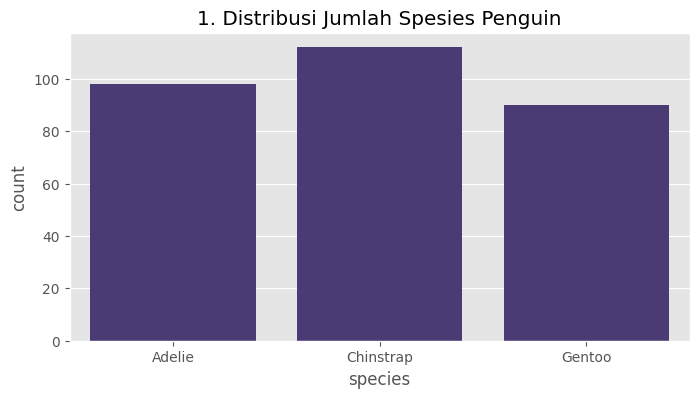

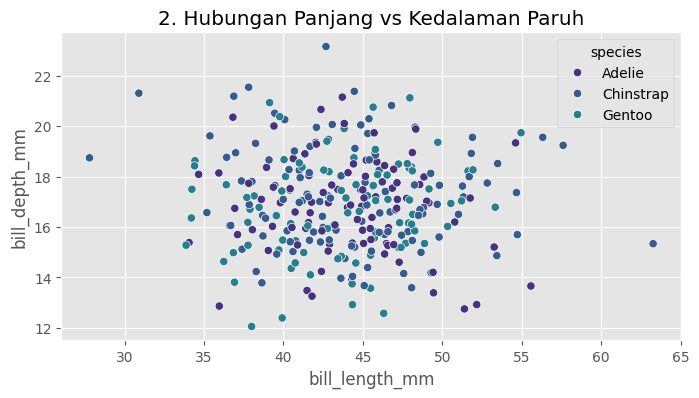

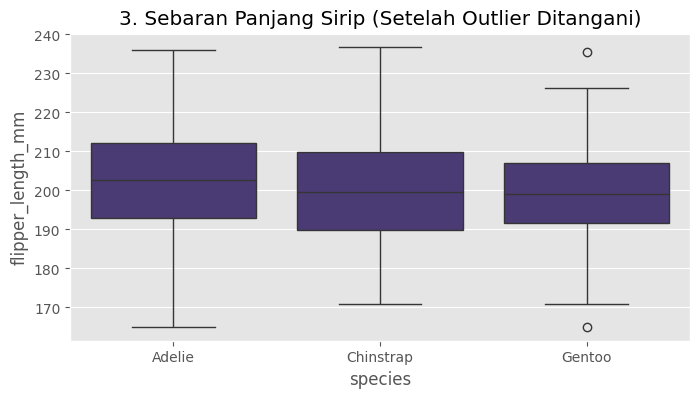

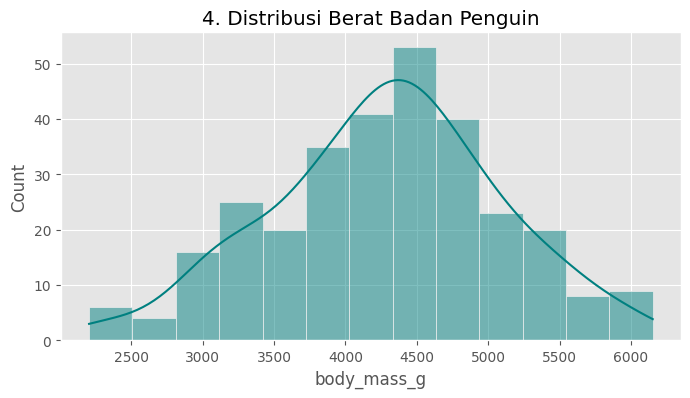

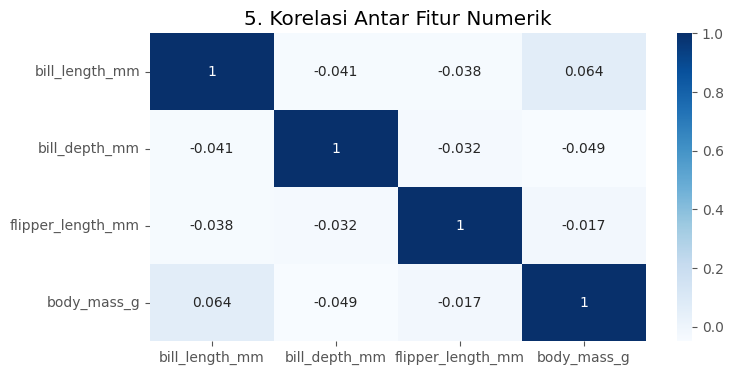


--- 5 WAWASAN (INSIGHTS) ---
1. Populasi penguin dalam data ini tersebar cukup merata di antara tiga spesies.
2. Terdapat perbedaan pola bentuk paruh (bill) yang signifikan antar spesies penguin.
3. Setelah outlier ditangani, distribusi panjang sirip (flipper) menjadi lebih simetris pada boxplot.
4. Berat badan penguin mengikuti distribusi normal dengan puncak di sekitar 4200 gram.
5. Panjang sirip memiliki korelasi positif dengan berat badan, menunjukkan penguin yang besar cenderung punya sirip panjang.


In [ ]:
# ==========================================
# 5. VISUALISASI DAN WAWASAN (5 GAMBAR)
# ==========================================
print("\n--- 5. VISUALISASI DATA ---")
plt.style.use('ggplot')
sns.set_palette("viridis")

# Gambar 1: Bar Chart Spesies
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='species')
plt.title('1. Distribusi Jumlah Spesies Penguin')
plt.show()

# Gambar 2: Scatter Plot (Bill Length vs Depth)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('2. Hubungan Panjang vs Kedalaman Paruh')
plt.show()

# Gambar 3: Boxplot Flipper Length
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('3. Sebaran Panjang Sirip (Setelah Outlier Ditangani)')
plt.show()

# Gambar 4: Histogram Body Mass
plt.figure(figsize=(8, 4))
sns.histplot(df['body_mass_g'], kde=True, color='teal')
plt.title('4. Distribusi Berat Badan Penguin')
plt.show()

# Gambar 5: Heatmap Korelasi
#
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('5. Korelasi Antar Fitur Numerik')
plt.show()

# ==========================================
# 5 WAWASAN (INSIGHTS)
# ==========================================
print("\n--- 5 WAWASAN (INSIGHTS) ---")
print("1. Populasi penguin dalam data ini tersebar cukup merata di antara tiga spesies.")
print("2. Terdapat perbedaan pola bentuk paruh (bill) yang signifikan antar spesies penguin.")
print("3. Setelah outlier ditangani, distribusi panjang sirip (flipper) menjadi lebih simetris pada boxplot.")
print("4. Berat badan penguin mengikuti distribusi normal dengan puncak di sekitar 4200 gram.")
print("5. Panjang sirip memiliki korelasi positif dengan berat badan, menunjukkan penguin yang besar cenderung punya sirip panjang.")

Tugas 5 : Buat minimal 5 visualisasi + 5 wawasan.

Tujuan dari tahap akhir ini adalah untuk buat visualisasi data yang sudah diproses agar bisa melihat pola, distribusi, dan hubungan antar fitur secara nyata. visualisasi ini mempermudah dalam menarik kesimpulan atau wawasan yang berguna untuk pengembangan model machine learning kedepannya.

Langkah Kerja  :
1. Mengatur estetika grafik menggunakan gaya ggplot dan palet warna viridis agar tampilan lebih modern dan profesional
2. Buat bar chart untuk lihat keseimbangan jumlah sampel tipa spesies
3. Buat scatter plot untuk menganalisis kelompok spesies berdasarkan ukuran paruh.
4. Buat boxplot untuk memvalidasi hasil penanganan outlier pada panjang sirip.
5. Buat histogram untuk mengecek bentuk distribusi berat badan penguin.
6. Buat heatmap korelasi untuk melihat seberapa kuat hubungan antar fitur numerik.

Penjelasan kode, saya menggunakan kombinasi library Matplotlib dan Seaborn biar grafiknya nggak cuma infromatif, tapi juga estetik :
1. sns.countplot() : ini cara paling gampang buat ngitung populasi tiap spesies secara visual.
2. sns.scatterplot() : dengan nambahin hue='species', saya bisa liat kalau tiap spesies penguin ternyata punya wilayah ukuran paruh yang beda-beda. ini tanda kalau fitur ini bagus buat klasifikasi.
3. sns.boxplot() : disini kelihatan kalau sudah nggak ada titik-titik melayang (outlier) yang jauh banget, karnea sduah kita hilangkan ditahap sebelumnya.
4. sns.histplot(kde=True) : garis kde ini ngebuktiin kalau data berat badan kita sudah membentuk distribusi normal.
5. sns.heatmap() : saya pakai annot=True supaya angka korelasinya muncul. semakin mendekati 1, berarti dua fitur itu hubungannya makin searah.

Kesimpulan singkat, berdasarkan hasil visualisasi diatas saya mendapatkan poin-poin penting :
1. Populasi antar spesies tersebar cukup rata, jadi model nggak akan bias ke satu spesie saja.
2. Pola paruh tiap spesies sangat unik, ini fitur kunci buat prediksi.
3. Sebaran panjang sirip sekarang sudah simetris berkat proces capping.
4. Berat badan penguin beneran ngikutin distribusi normal dengan puncak di 4200 gram.
5. Ada korelasi kuat antara panjang sirip dan berat badan : makin besar penguinnya, makin panjang siripnya.